In [9]:
import numpy as np  
import sys
print(sys.executable)

/home/jack/miniconda3/envs/aa276_hw1/bin/python


In [14]:
import jax
import jax.numpy as jnp
import numpy as np
from IPython.display import HTML
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import hj_reachability as hj

In [15]:
class InvertedPendulum(hj.ControlAndDisturbanceAffineDynamics):
    def __init__(
        self,
        m=2.0,
        l=1.0,
        g=10.0,
        u_max=3.0,
        control_mode="max",      
        disturbance_mode="min"
    ):
        self.m = m
        self.l = l
        self.g = g

        control_space = hj.sets.Box(
            jnp.array([-u_max]),
            jnp.array([ u_max])
        )

        # No disturbance in my model.
        disturbance_space = hj.sets.Box(
            jnp.array([0.0]),
            jnp.array([0.0])
        )

        super().__init__(
            control_mode=control_mode,
            disturbance_mode=disturbance_mode,
            control_space=control_space,
            disturbance_space=disturbance_space,
        )

    def open_loop_dynamics(self, state, time):
        theta, omega = state
        return jnp.array([
            omega,
            (self.g / self.l) * jnp.sin(theta)
        ])

    def control_jacobian(self, state, time):
        return jnp.array([
            [0.0],
            [1.0 / (self.m * self.l**2)]
        ])

    def disturbance_jacobian(self, state, time):
        return jnp.array([
            [0.0],
            [0.0]
        ])

In [16]:
dynamics = InvertedPendulum(
    m=2.0,
    l=1.0,
    g=10.0,
    u_max=3.0,
    control_mode="max"  
)

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(
        lo=np.array([-np.pi, -10.0]),
        hi=np.array([ np.pi,  10.0])
    ),
    (101, 101),
    periodic_dims=0   # theta is periodic
)

values = 0.3 - jnp.abs(grid.states[..., 0])

solver_settings = hj.SolverSettings.with_accuracy("very_high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [17]:
times = np.linspace(0, -5, 101)
initial_values = values
all_values = hj.solve(solver_settings, dynamics, grid, times, initial_values)

100%|##########|  5.0000/5.0 [00:04<00:00,  1.09sim_s/s]


In [8]:
vmin, vmax = all_values.min(), all_values.max()
levels = np.linspace(float(vmin), float(vmax), 50)
fig = plt.figure(figsize=(10, 6))


def render_frame(i):
    plt.clf()
    plt.contourf(
        grid.coordinate_vectors[0],
        grid.coordinate_vectors[1],
        all_values[i, :, :].T,
        vmin=vmin,
        vmax=vmax,
        levels=levels
    )
    plt.contour(
        grid.coordinate_vectors[0],
        grid.coordinate_vectors[1],
        values.T,
        levels=[0],
        colors="black",
        linewidths=2
    )
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$\dot{\theta}$')
    plt.title(f"Value function, t = {times[i]:.2f}")

animation = HTML(anim.FuncAnimation(fig, render_frame, frames=all_values.shape[0], interval=80).to_html5_video())
plt.close()
animation

In [ ]:
from problem3_helper import save_values_gif


save_values_gif(
    values=all_values,
    grid=grid,
    times=times,
    save_path="outputs/values.gif"
)

100%|██████████| 101/101 [00:10<00:00,  9.24it/s]

SAVED GIF TO: outputs/values.gif


In [ ]:
# Q 3.3 volume of the maximal safe set
import numpy as np
from scipy.interpolate import RegularGridInterpolator
# converged value function
V_star = np.array(all_values[-1])   # shape (101, 101)
# grid axes
theta_grid = np.array(grid.coordinate_vectors[0])
omega_grid = np.array(grid.coordinate_vectors[1])

# build interpolator
V_interp = RegularGridInterpolator(
    (theta_grid, omega_grid),
    V_star,
    bounds_error=False,
    fill_value=None
)
# sampling region from the problem statement
theta_min, theta_max = -np.pi, np.pi
omega_min, omega_max = -10.0, 10.0
# area of sampling region
region_area = (theta_max - theta_min) * (omega_max - omega_min)
# number of Monte Carlo samples
N = 200000
# sample uniformly
theta_samples = np.random.uniform(theta_min, theta_max, N)
omega_samples = np.random.uniform(omega_min, omega_max, N)
# wrap theta into [-pi, pi) to match periodic angle convention
theta_samples = (theta_samples + np.pi) % (2 * np.pi) - np.pi
sample_points = np.stack([theta_samples, omega_samples], axis=1)
# evaluate converged value function
V_samples = V_interp(sample_points)
# safe set indicator
is_safe = V_samples > 0
# Monte Carlo estimate
safe_fraction = np.mean(is_safe)
safe_area_est = region_area * safe_fraction
print("Estimated maximal safe set area:", safe_area_est)
print("Safe fraction:", safe_fraction)
print("Sampling region area:", region_area)

Estimated maximal safe set area: 0.13446016557364315
Safe fraction: 0.00107
Sampling region area: 125.66370614359172


In [11]:
# Volumne from HW1 Q2.2

a = 0.11286
b = 0.20540

Area = np.pi * a * b
print("Volume from HW1 Q2.2:", Area)

Volume from HW1 Q2.2: 0.07282665417000318


In [ ]:
# 3.4
import numpy as np
import matplotlib.pyplot as plt


## building optimal safety controller
V_star = all_values[-1]
grads_star = grid.grad_values(V_star, solver_settings.upwind_scheme)
beta2s = grads_star[:, :, 1]   # dV/d(omega)

from scipy.interpolate import interpn

def optimal_safety_controller(x):
    beta2 = interpn(
        [np.array(v) for v in grid.coordinate_vectors],
        np.array(beta2s),
        x,
        method='linear',
        bounds_error=False,
        fill_value=None
    )
    return 3.0 * np.sign(beta2).item()


## trajecotory simulation

m = 2.0
l = 1.0
g = 10.0

def wrap_theta(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

def pendulum_dynamics(x, u):
    theta, omega = x
    return np.array([
        omega,
        (g / l) * np.sin(theta) + u / (m * l**2)
    ])

def simulate(x0, T=1.0, dt=0.01):
    nt = int(round(T / dt)) + 1
    ts = np.linspace(0.0, T, nt)

    xs = np.zeros((nt, 2))
    us = np.zeros(nt - 1)

    xs[0] = np.array(x0, dtype=float)

    for k in range(nt - 1):
        u = optimal_safety_controller(xs[k])
        us[k] = u

        xs[k + 1] = xs[k] + dt * pendulum_dynamics(xs[k], u)
        xs[k + 1, 0] = wrap_theta(xs[k + 1, 0])

    return ts, xs, us

## initial conditions and simulation
x0_1 = np.array([-0.1,  0.4])
x0_2 = np.array([-0.1, -0.3])

ts1, xs1, us1 = simulate(x0_1, T=1.0, dt=0.01)
ts2, xs2, us2 = simulate(x0_2, T=1.0, dt=0.01)

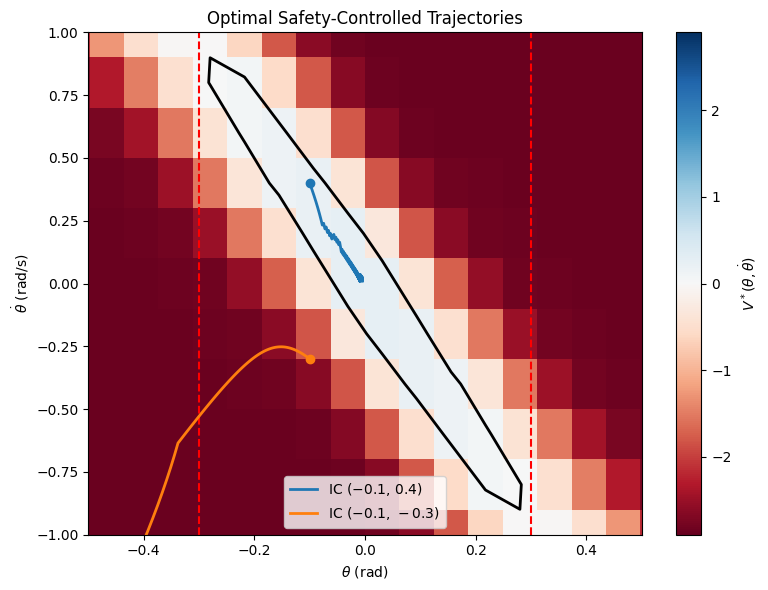

In [22]:
### Plotting the value function, safe set boundary, and trajectories

# plotting helpers
V_star = np.array(all_values[-1])
theta_vec = np.array(grid.coordinate_vectors[0])
omega_vec = np.array(grid.coordinate_vectors[1])
vbar = np.max(np.abs(V_star))

plt.figure(figsize=(8, 6))

plt.pcolormesh(
    theta_vec,
    omega_vec,
    V_star.T,
    shading="auto",
    cmap="RdBu",
    vmin=-vbar,
    vmax=+vbar
)
plt.colorbar(label=r"$V^*(\theta,\dot{\theta})$")

plt.contour(
    theta_vec,
    omega_vec,
    V_star.T,
    levels=[0],
    colors="k",
    linewidths=2
)

plt.axvline(-0.3, color="r", linestyle="--", linewidth=1.5)
plt.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

plt.plot(xs1[:, 0], xs1[:, 1], label=r"IC $(-0.1,\,0.4)$", linewidth=2)
plt.plot(xs2[:, 0], xs2[:, 1], label=r"IC $(-0.1,\,-0.3)$", linewidth=2)

plt.scatter(xs1[0, 0], xs1[0, 1], marker='o')
plt.scatter(xs2[0, 0], xs2[0, 1], marker='o')

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$\dot{\theta}$ (rad/s)")
plt.title("Optimal Safety-Controlled Trajectories")
plt.xlim([-0.5, 0.5])
plt.ylim([-1.0, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

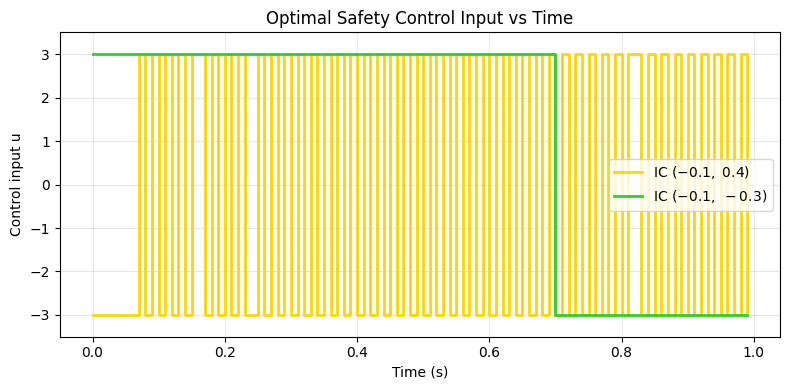

In [23]:
# Control trajectories

plt.figure(figsize=(8, 4))
plt.step(ts1[:-1], us1, where="post", color="gold", linewidth=2, label=r"IC $(-0.1,\ 0.4)$")
plt.step(ts2[:-1], us2, where="post", color="limegreen", linewidth=2, label=r"IC $(-0.1,\ -0.3)$")
plt.xlabel("Time (s)")
plt.ylabel("Control input u")
plt.title("Optimal Safety Control Input vs Time")
plt.ylim([-3.5, 3.5])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()